# InfoGAN
*Please note that this is an optional notebook meant to introduce more advanced concepts. If you’re up for a challenge, take a look and don’t worry if you can’t follow everything. There is no code to implement—only some cool code for you to learn and run!*

### Goals

In this notebook, you're going to learn about InfoGAN in order to generate disentangled outputs, based on the paper, [InfoGAN: Interpretable Representation Learning by Information Maximizing Generative Adversarial Nets](https://arxiv.org/abs/1606.03657) by Chen et. al. While there are many approaches to disentanglement, this is one of the more widely used and better known. 

InfoGAN can be understood like this: you want to separate your model into two parts: $z$, corresponding to truly random noise, and $c$ corresponding to the "latent code." The latent code $c$ which can be thought of as a "hidden" condition in a conditional generator, and you'd like it to have an interpretable meaning. 

Now, you'll likely immediately wonder, how do they get $c$, which is just some random set of numbers, to be more interpretable than any dimension in a typical GAN? The answer is "mutual information": essentially, you would like each dimension of the latent code to be as obvious a function as possible of the generated images. Read on for a more thorough theoretical and practical treatment.

### Formally: Variational Lower Bound
The [information entropy](https://en.wikipedia.org/wiki/Entropy_(information_theory)) ${H} (X)=-\sum _{i=1}^{n}{P(x_{i})\log P (x_{i})}$
can be understood to the amount of "information" in the distribution $X$. For example, the information entropy of $n$ fair coins is $n$ bits. You've also seen a similar equation before: the cross-entropy loss. Moreover, mutual information $I(X;Y) = H(X) - H(X\vert Y)$, which the authors of InfoGAN describe as (intuitively) the "reduction of uncertainty in $X$ when $Y$ is observed." 

In InfoGAN, you'd like to maximize $I(c; G(z, c))$, the mutual information between the latent code $c$ and the generated images $G(z, c)$.  Since it's difficult to know $P(c | G(z, c))$, you add a second output to the discriminator to predict $P(c | G(z, c))$. 

Let $\Delta = D_{KL}(P(\cdot|x) \Vert Q(\cdot|x))$, the [Kullback-Leibler_divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) between the true and approximate distribution. Then, based on Equation 4 in the paper, the mutual information has the following lower bound: 
$$\begin{split}
I(c; G(z, c)) & = H(c) - H(c|G(z, c)) \\
& = {\mathbb{E}}_{x \sim G(z, c)} [ {\mathbb{E}}_{c' \sim P(c, x)} \log P(c' | x) ] + H(c) \textit{ (by definition of H)}\\
& = {\mathbb{E}}_{x \sim G(z, c)} [\Delta + {\mathbb{E}}_{c' \sim P(c, x)} \log Q(c' | x) ] + H(c) \textit{ (approximation error)}\\
& \geq {\mathbb{E}}_{x \sim G(z, c)} [{\mathbb{E}}_{c' \sim P(c, x)} \log Q(c' | x) ] + H(c) \textit{ (KL divergence is non-negative)}\\
\end{split}
$$

For a given latent code distribution, $H(c)$ is fixed, so the following makes a good loss:

$${\mathbb{E}}_{x \sim G(z, c)} [{\mathbb{E}}_{c' \sim P(c, x)} \log Q(c' | x) ]$$

Which is the mean cross entropy loss of the approximation over the generator's images. 

### Updating the Minimax Game

A vanilla generator and discriminator follow a minimax game: $\displaystyle \min_{G} \max_{D} V(D, G) = \mathbb{E}(\log D(x)) + \mathbb{E}(\log (1 - D(G(z))))$.

To encourage mutual information, this game is updated for $Q$ to maximize mutual information: $\displaystyle \min_{G, Q} \max_{D} V(D, G) - \lambda I(c; G(z, c))$

## Implementing InfoGAN

For this notebook, you'll be using the MNIST dataset again. 

You will begin by importing the necessary libraries and building the generator and discriminator. The generator will be the same as before, but the discriminator will be modified with more dimensions in its output.

#### Packages and Visualization

In [1]:
import torch
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(0) # Set for our testing purposes, please do not change!

def show_tensor_images(image_tensor, num_images=25, size=(1, 28, 28), nrow=5, show=True):
    '''
    Function for visualizing images: Given a tensor of images, number of images, and
    size per image, plots and prints the images in an uniform grid.
    '''
    image_tensor = (image_tensor + 1) / 2
    image_unflat = image_tensor.detach().cpu()
    image_grid = make_grid(image_unflat[:num_images], nrow=nrow)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    if show:
        plt.show()

#### Generator and Noise

In [2]:
class Generator(nn.Module):
    '''
    Generator Class
    Values:
        input_dim: the dimension of the input vector, a scalar
        im_chan: the number of channels in the images, fitted for the dataset used, a scalar
              (MNIST is black-and-white, so 1 channel is your default)
        hidden_dim: the inner dimension, a scalar
    '''
    def __init__(self, input_dim=10, im_chan=1, hidden_dim=64):
        super(Generator, self).__init__()
        self.input_dim = input_dim
        # Build the neural network
        self.gen = nn.Sequential(
            self.make_gen_block(input_dim, hidden_dim * 4),
            self.make_gen_block(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=1),
            self.make_gen_block(hidden_dim * 2, hidden_dim),
            self.make_gen_block(hidden_dim, im_chan, kernel_size=4, final_layer=True),
        )

    def make_gen_block(self, input_channels, output_channels, kernel_size=3, stride=2, final_layer=False):
        '''
        Function to return a sequence of operations corresponding to a generator block of DCGAN;
        a transposed convolution, a batchnorm (except in the final layer), and an activation.
        Parameters:
            input_channels: how many channels the input feature representation has
            output_channels: how many channels the output feature representation should have
            kernel_size: the size of each convolutional filter, equivalent to (kernel_size, kernel_size)
            stride: the stride of the convolution
            final_layer: a boolean, true if it is the final layer and false otherwise 
                      (affects activation and batchnorm)
        '''
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace=True),
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.Tanh(),
            )

    def forward(self, noise):
        '''
        Function for completing a forward pass of the generator: Given a noise tensor, 
        returns generated images.
        Parameters:
            noise: a noise tensor with dimensions (n_samples, input_dim)
        '''
        x = noise.view(len(noise), self.input_dim, 1, 1)
        return self.gen(x)

def get_noise(n_samples, input_dim, device='cpu'):
    '''
    Function for creating noise vectors: Given the dimensions (n_samples, input_dim)
    creates a tensor of that shape filled with random numbers from the normal distribution.
    Parameters:
        n_samples: the number of samples to generate, a scalar
        input_dim: the dimension of the input vector, a scalar
        device: the device type
    '''
    return torch.randn(n_samples, input_dim, device=device)

#### InfoGAN Discriminator

You update the final layer to predict a distribution for $c$ from $x$, alongside the traditional discriminator output. Since you're assuming a normal prior in this assignment, you output a mean and a log-variance prediction.

In [3]:
class Discriminator(nn.Module):
    '''
    Discriminator Class
    Values:
      im_chan: the number of channels in the images, fitted for the dataset used, a scalar
            (MNIST is black-and-white, so 1 channel is your default)
      hidden_dim: the inner dimension, a scalar
      c_dim: the number of latent code dimensions - 
    '''
    def __init__(self, im_chan=1, hidden_dim=64, c_dim=10):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            self.make_disc_block(im_chan, hidden_dim),
            self.make_disc_block(hidden_dim, hidden_dim * 2),
        )
        self.d_layer = self.make_disc_block(hidden_dim * 2, 1, final_layer=True)
        self.q_layer = nn.Sequential(
            self.make_disc_block(hidden_dim * 2, hidden_dim * 2),
            self.make_disc_block(hidden_dim * 2, 2 * c_dim, kernel_size=1, final_layer=True)
        )

    def make_disc_block(self, input_channels, output_channels, kernel_size=4, stride=2, final_layer=False):
        '''
        Function to return a sequence of operations corresponding to a discriminator block of the DCGAN; 
        a convolution, a batchnorm (except in the final layer), and an activation (except in the final layer).
        Parameters:
            input_channels: how many channels the input feature representation has
            output_channels: how many channels the output feature representation should have
            kernel_size: the size of each convolutional filter, equivalent to (kernel_size, kernel_size)
            stride: the stride of the convolution
            final_layer: a boolean, true if it is the final layer and false otherwise 
                      (affects activation and batchnorm)
        '''
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace=True),
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
            )

    def forward(self, image):
        '''
        Function for completing a forward pass of the discriminator: Given an image tensor, 
        returns a 1-dimension tensor representing fake/real.
        Parameters:
            image: a flattened image tensor with dimension (im_chan)
        '''
        intermediate_pred = self.disc(image)
        disc_pred = self.d_layer(intermediate_pred)
        q_pred = self.q_layer(intermediate_pred)
        return disc_pred.view(len(disc_pred), -1), q_pred.view(len(q_pred), -1)

## Helper Functions

You can include some helper functions for conditional GANs:

In [4]:
def combine_vectors(x, y):
    '''
    Function for combining two vectors with shapes (n_samples, ?) and (n_samples, ?).
    Parameters:
      x: (n_samples, ?) the first vector. 
        This will be the noise vector of shape (n_samples, z_dim).
      y: (n_samples, ?) the second vector.
        Once again, in this assignment this will be the one-hot class vector 
        with the shape (n_samples, n_classes).
    '''
    combined = torch.cat([x.float(), y.float()], 1)
    return combined

## Training

Let's include the same parameters from previous assignments, as well as a new `c_dim` dimension for the dimensionality of the InfoGAN latent code, a `c_criterion`, and its corresponding constant, `c_lambda`:

  *   mnist_shape: the number of pixels in each MNIST image, which has dimensions 28 x 28 and one channel (because it's black-and-white) so 1 x 28 x 28
  *   adv_criterion: the vanilla GAN loss function
  *   c_criterion: the additional mutual information term
  *   c_lambda: the weight on the c_criterion
  *   n_epochs: the number of times you iterate through the entire dataset when training
  *   z_dim: the dimension of the noise vector
  *   c_dim: the dimension of the InfoGAN latent code
  *   display_step: how often to display/visualize the images
  *   batch_size: the number of images per forward/backward pass
  *   lr: the learning rate
  *   device: the device type


In [5]:
from torch.distributions.normal import Normal
adv_criterion = nn.BCEWithLogitsLoss()
c_criterion = lambda c_true, mean, logvar: Normal(mean, logvar.exp()).log_prob(c_true).mean()
c_lambda = 0.1
mnist_shape = (1, 28, 28)
n_epochs = 80
z_dim = 64
c_dim = 2
display_step = 500
batch_size = 128
# InfoGAN uses two different learning rates for the models
d_lr = 2e-4
g_lr = 1e-3
device = 'cuda'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataloader = DataLoader(
    MNIST('.', download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True)

You initialize your networks as usual - notice that there is no separate $Q$ network. There are a few "design" choices worth noting here: 
1. There are many possible choices for the distribution over the latent code. You use a Gaussian prior here, but a categorical (discrete) prior is also possible, and in fact it's possible to use them together. In this case, it's also possible to use different weights $\lambda$ on both prior distributions. 
2. You can calculate the mutual information explicitly, including $H(c)$ which you treat as constant here. You don't do that here since you're not comparing the mutual information of different parameterizations of the latent code.
3. There are multiple ways to handle the $Q$ network - this code follows the original paper by treating it as part of the discriminator, sharing most weights, but it is also possible to simply initialize another network.

In [6]:
gen = Generator(input_dim=z_dim + c_dim).to(device)
gen_opt = torch.optim.Adam(gen.parameters(), lr=g_lr)
disc = Discriminator(im_chan=mnist_shape[0], c_dim=c_dim).to(device)
disc_opt = torch.optim.Adam(disc.parameters(), lr=d_lr)

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)
gen = gen.apply(weights_init)
disc = disc.apply(weights_init)

Now let's get to training the networks:

Epoch 1, step 500: Generator loss: 3.167040228128433, discriminator loss: 0.26804572267830373


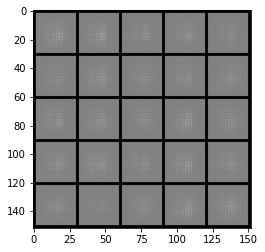

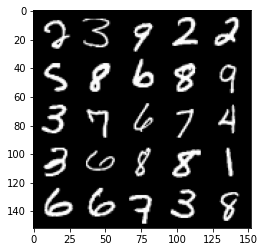

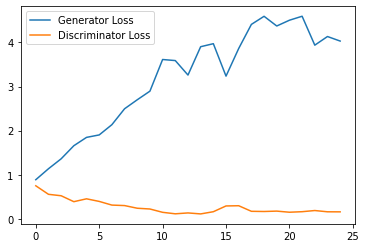

Epoch 2, step 1000: Generator loss: 4.934055043935776, discriminator loss: 0.13977463839948176


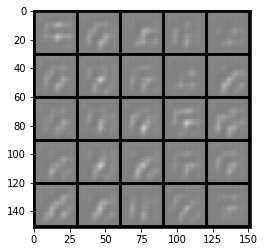

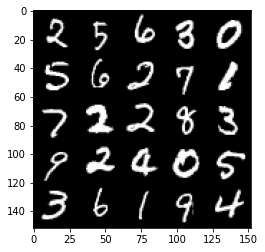

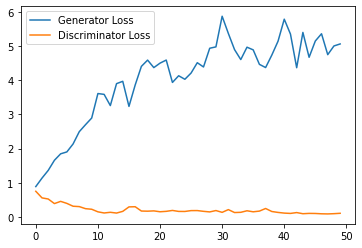

Epoch 3, step 1500: Generator loss: 5.62576796913147, discriminator loss: 0.06386134191974997


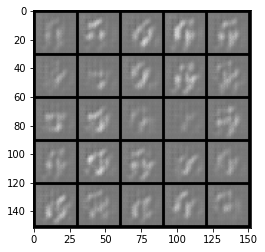

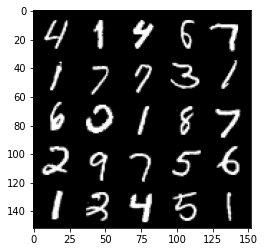

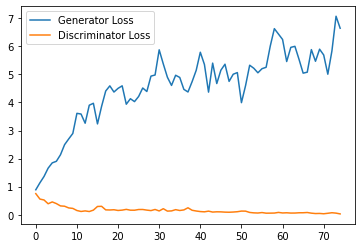

Epoch 4, step 2000: Generator loss: 7.299990788936615, discriminator loss: 0.03867933855205774


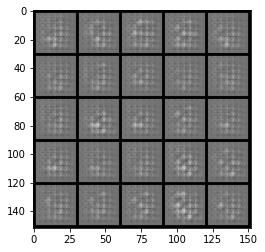

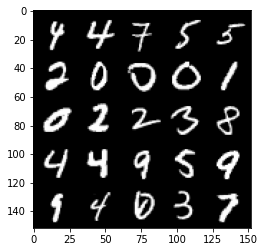

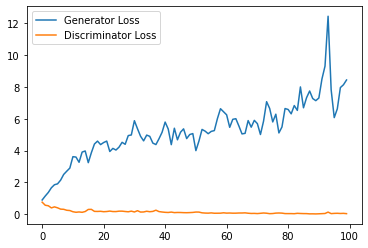

Epoch 5, step 2500: Generator loss: 7.22751990032196, discriminator loss: 0.018127896378631703


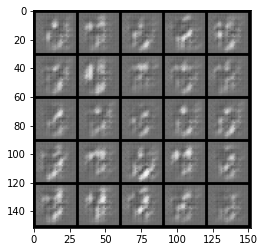

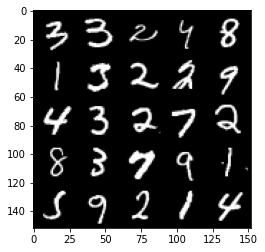

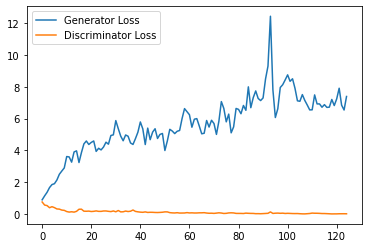

Epoch 6, step 3000: Generator loss: 6.128618523299694, discriminator loss: 0.07348163625225425


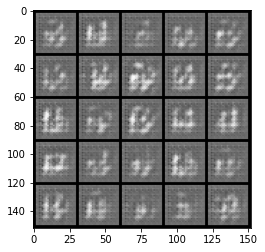

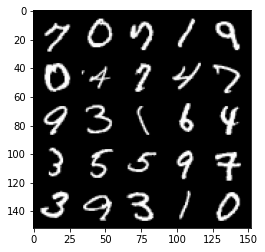

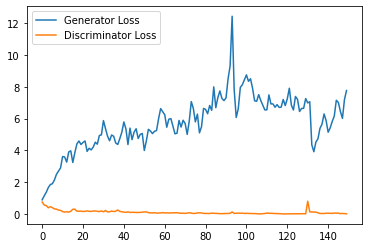

Epoch 7, step 3500: Generator loss: 6.576067698478699, discriminator loss: 0.018338050487218423


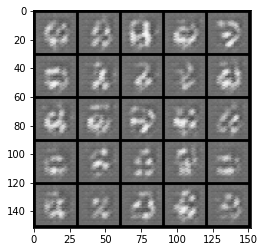

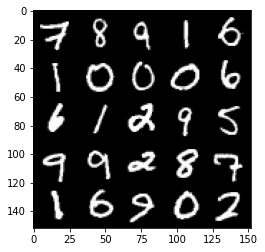

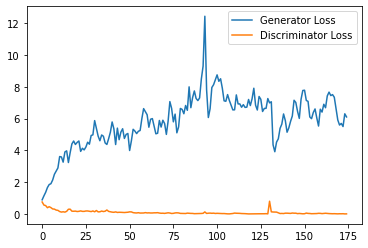

Epoch 8, step 4000: Generator loss: 5.855025008678436, discriminator loss: 0.005622400925960392


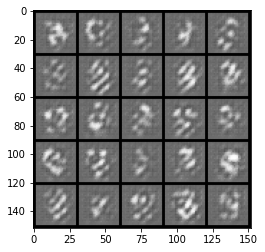

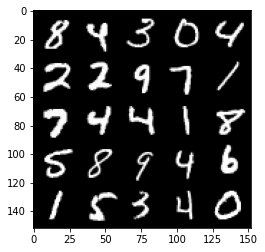

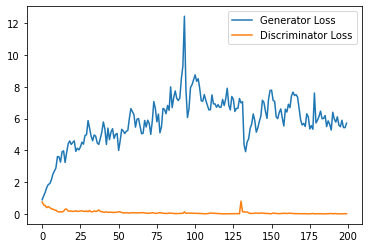

Epoch 9, step 4500: Generator loss: 6.120405224323273, discriminator loss: 0.00456536200735718


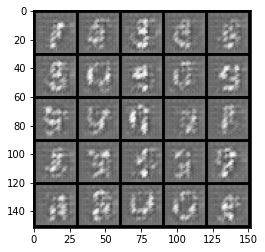

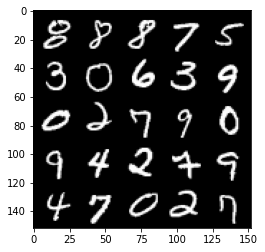

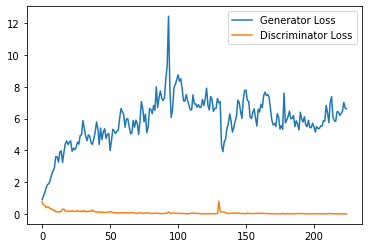

Epoch 10, step 5000: Generator loss: 6.476000558018685, discriminator loss: 0.03779529040493071


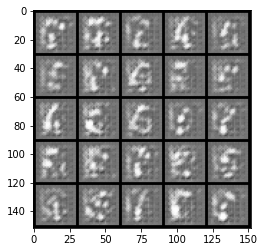

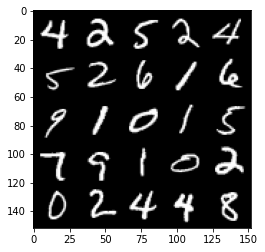

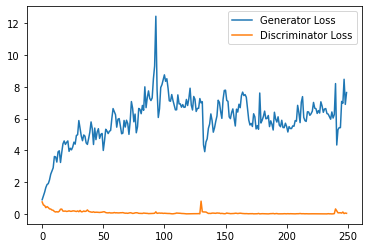

Epoch 11, step 5500: Generator loss: 5.729816679954529, discriminator loss: 0.015548398130573333


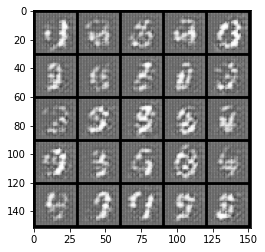

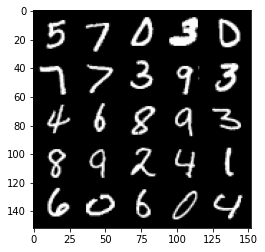

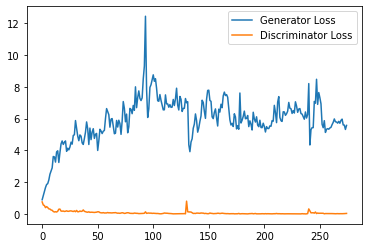

Epoch 12, step 6000: Generator loss: 6.4228900343179705, discriminator loss: 0.03541759544122033


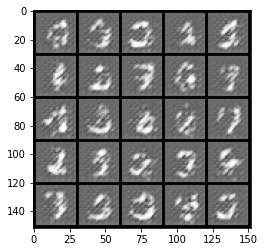

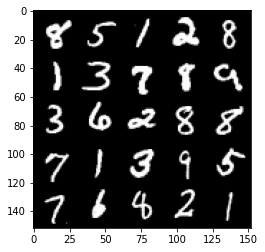

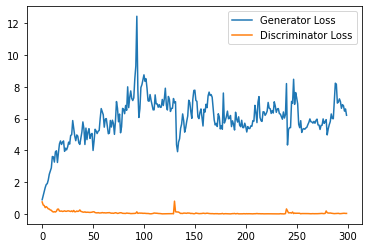

Epoch 13, step 6500: Generator loss: 6.182984417915344, discriminator loss: 0.025776191210839898


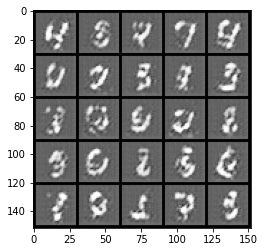

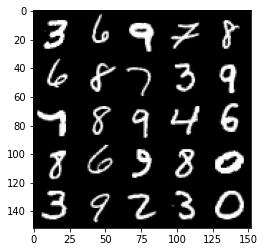

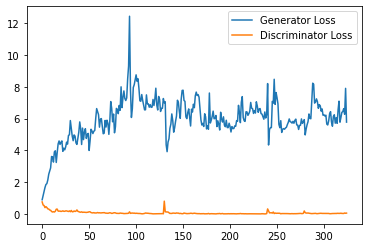

Epoch 14, step 7000: Generator loss: 6.466840156555175, discriminator loss: 0.055049508850090204


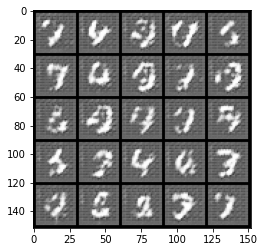

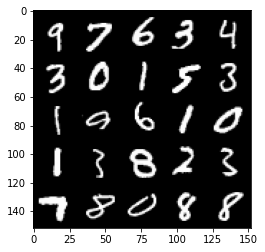

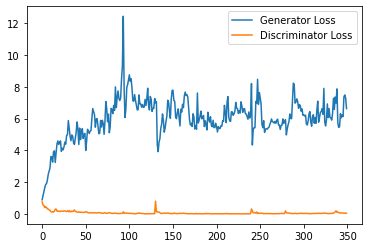

Epoch 15, step 7500: Generator loss: 5.5336820855140685, discriminator loss: 0.057636146329343316


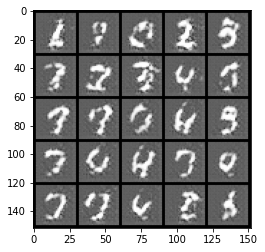

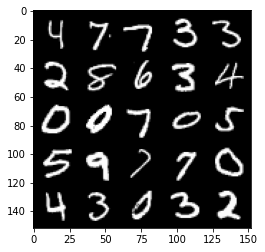

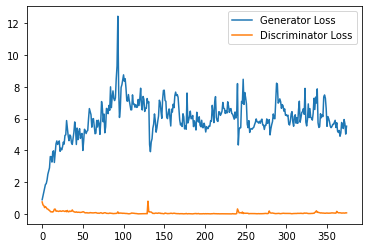

Epoch 17, step 8000: Generator loss: 5.818827602744102, discriminator loss: 0.09279959550499917


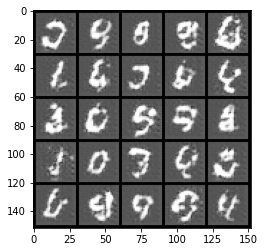

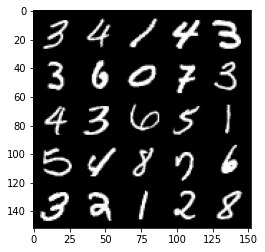

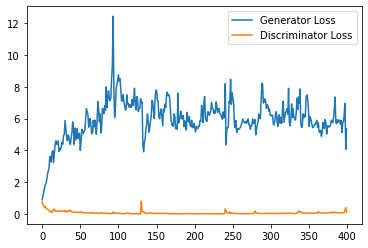

Epoch 18, step 8500: Generator loss: 6.390405876636505, discriminator loss: 0.08578228798508644


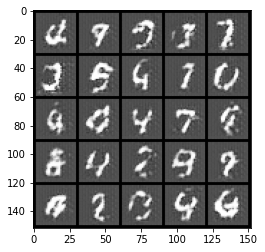

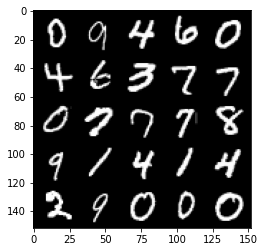

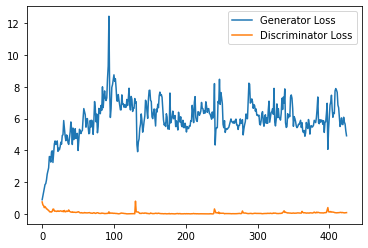

Epoch 19, step 9000: Generator loss: 5.637216531038284, discriminator loss: 0.08476102903485298


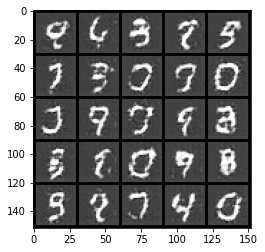

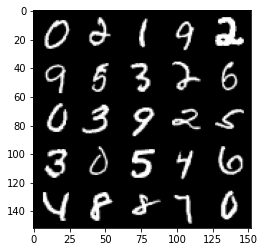

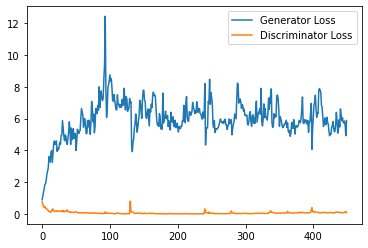

Epoch 20, step 9500: Generator loss: 5.5218742909431455, discriminator loss: 0.11271381099522114


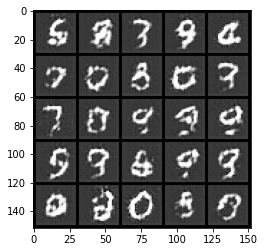

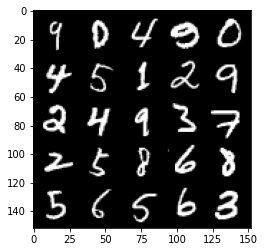

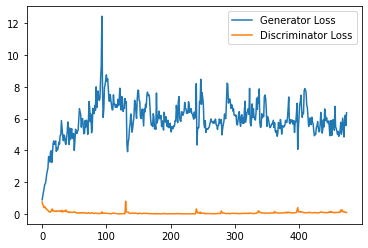

Epoch 21, step 10000: Generator loss: 5.226604416131973, discriminator loss: 0.11670769383013248


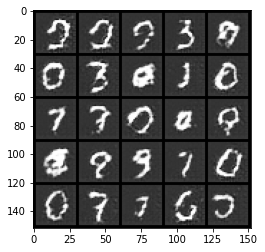

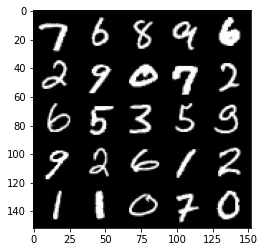

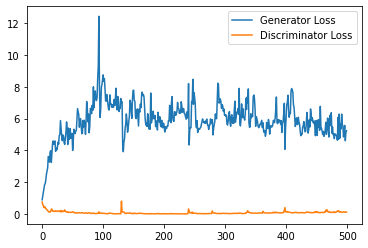

Epoch 22, step 10500: Generator loss: 5.1316748850345615, discriminator loss: 0.13710587410628797


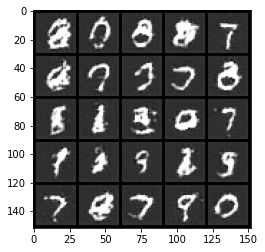

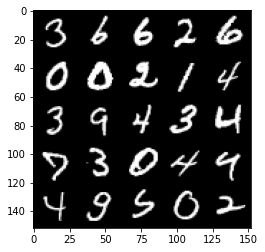

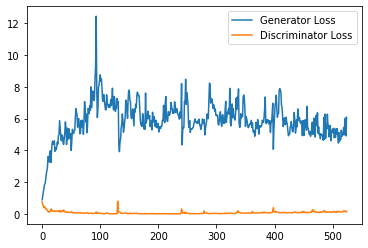

Epoch 23, step 11000: Generator loss: 4.729004925727844, discriminator loss: 0.14669813318550587


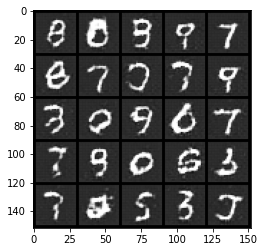

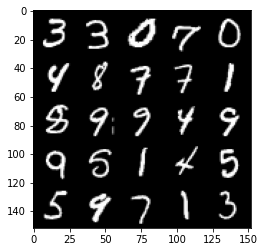

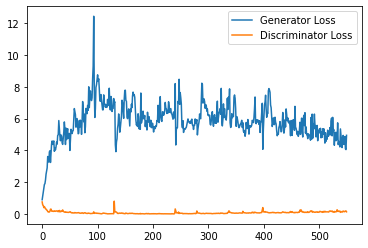

Epoch 24, step 11500: Generator loss: 4.452961914777756, discriminator loss: 0.17711261761188507


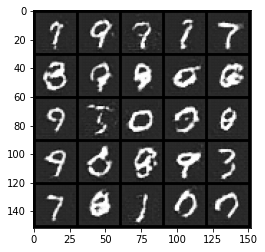

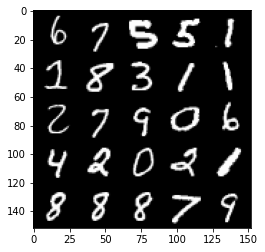

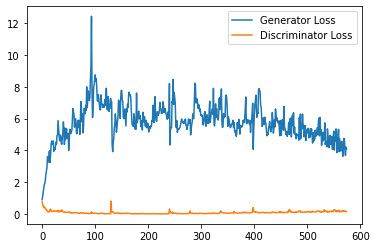

Epoch 25, step 12000: Generator loss: 4.153380656480789, discriminator loss: 0.18515914358198643


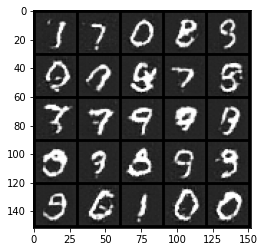

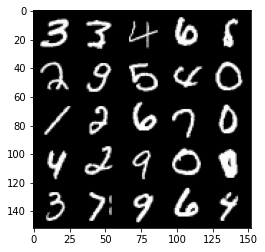

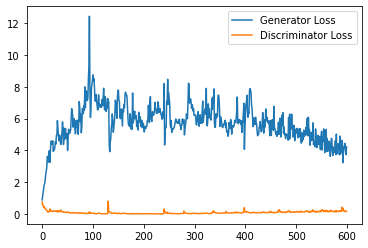

Epoch 26, step 12500: Generator loss: 3.9479361569881437, discriminator loss: 0.18386704057455064


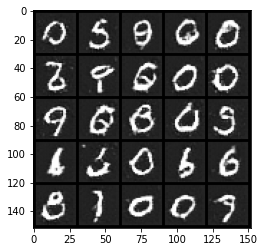

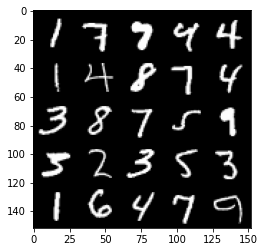

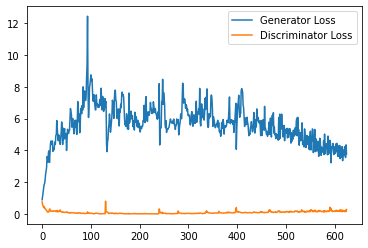

Epoch 27, step 13000: Generator loss: 4.063976177215576, discriminator loss: 0.19696425104141235


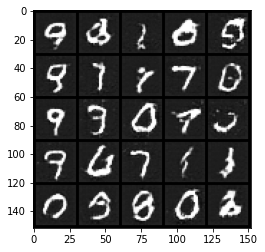

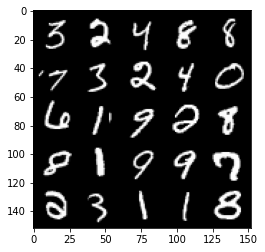

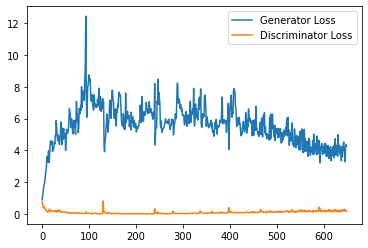

Epoch 28, step 13500: Generator loss: 3.8123042097091675, discriminator loss: 0.23499093514680863


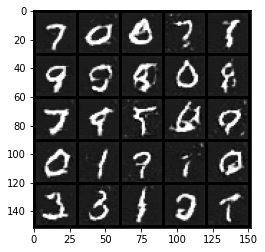

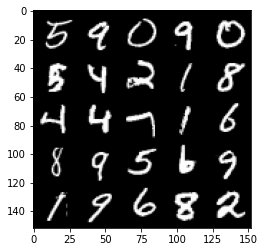

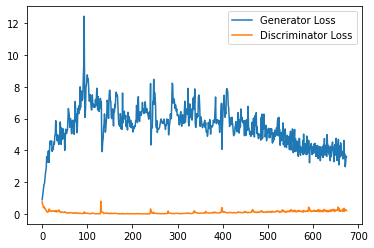

Epoch 29, step 14000: Generator loss: 3.564532298564911, discriminator loss: 0.24171543024480344


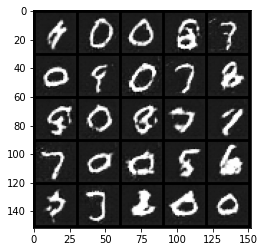

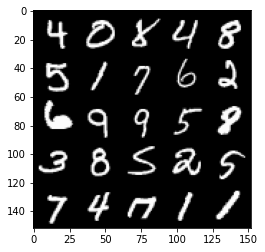

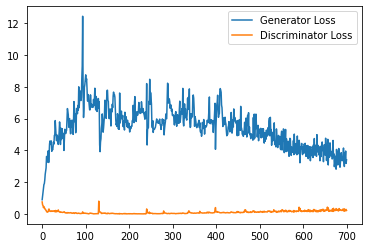

Epoch 30, step 14500: Generator loss: 3.525953214406967, discriminator loss: 0.2253201840519905


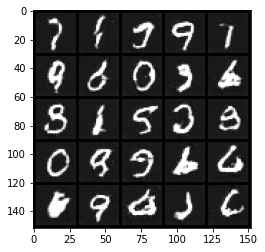

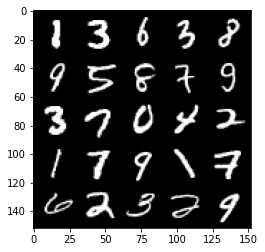

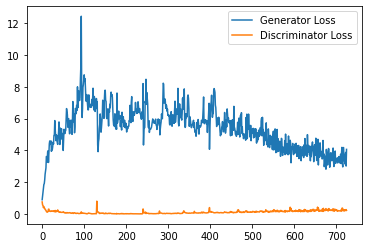

Epoch 31, step 15000: Generator loss: 3.465760036468506, discriminator loss: 0.23348198588192462


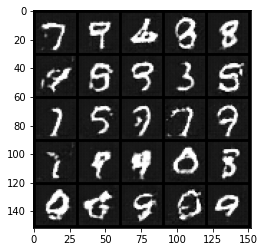

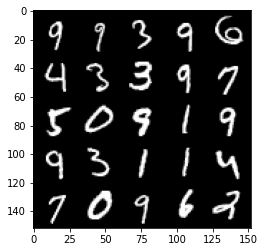

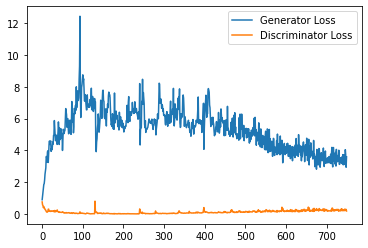

Epoch 33, step 15500: Generator loss: 3.362176615357399, discriminator loss: 0.24513046769797803


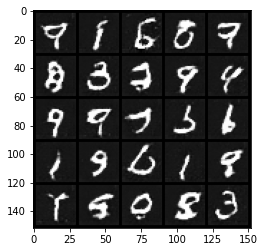

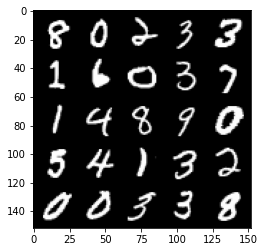

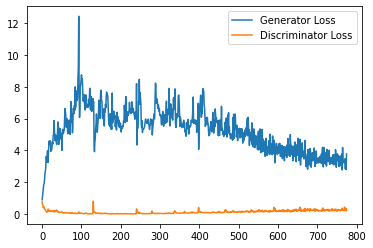

Epoch 34, step 16000: Generator loss: 3.168489579319954, discriminator loss: 0.2683380576968193


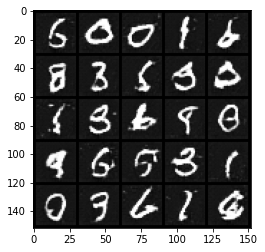

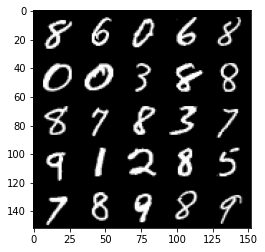

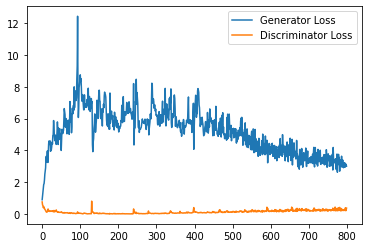

Epoch 35, step 16500: Generator loss: 3.2488120551109314, discriminator loss: 0.2606092303842306


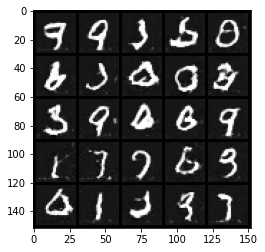

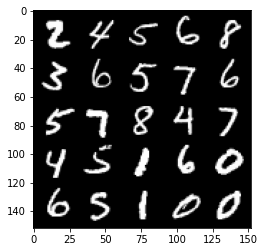

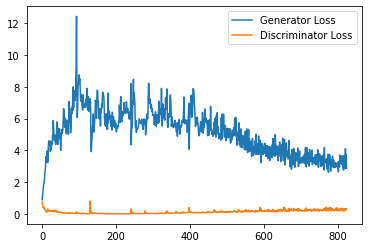

Epoch 36, step 17000: Generator loss: 3.16798055934906, discriminator loss: 0.2684578493535519


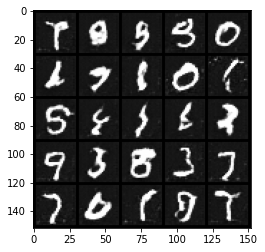

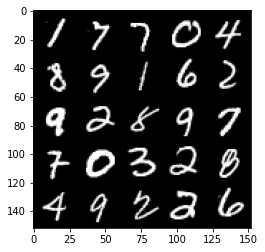

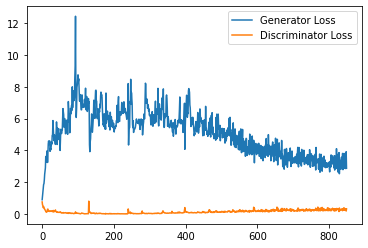

Epoch 37, step 17500: Generator loss: 3.139405228614807, discriminator loss: 0.2693894495666027


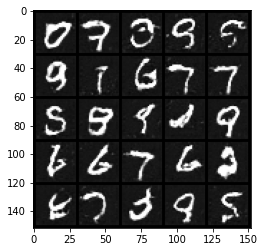

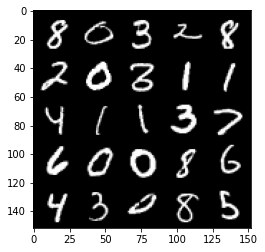

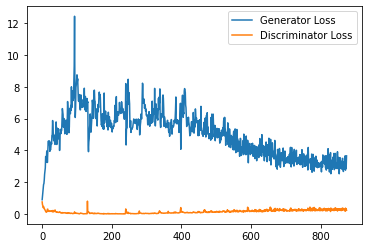

Epoch 38, step 18000: Generator loss: 3.122336815595627, discriminator loss: 0.2813077694773674


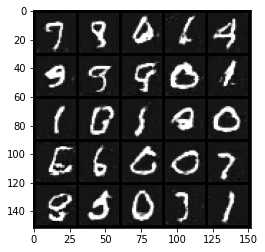

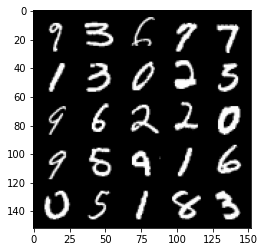

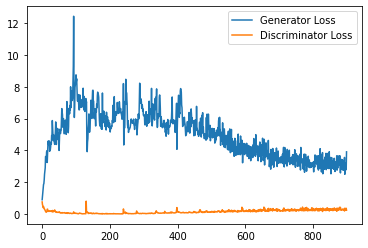

Epoch 39, step 18500: Generator loss: 3.090659918129444, discriminator loss: 0.2735979157090187


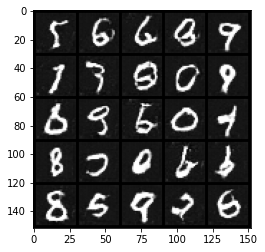

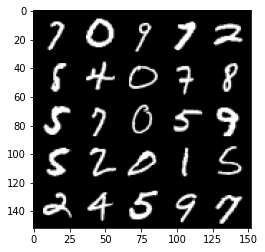

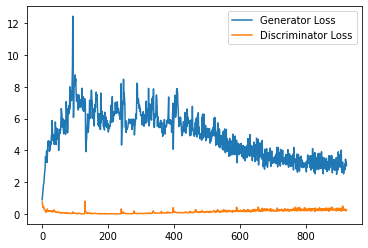

Epoch 40, step 19000: Generator loss: 3.0913102478981016, discriminator loss: 0.2716540338099003


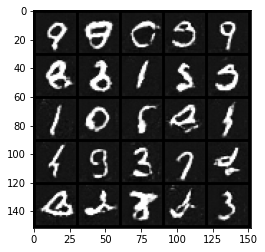

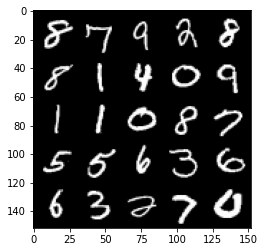

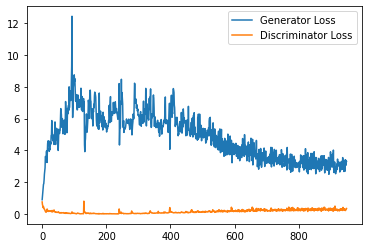

Epoch 41, step 19500: Generator loss: 3.0277226293087005, discriminator loss: 0.2885069041252136


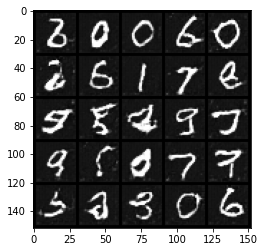

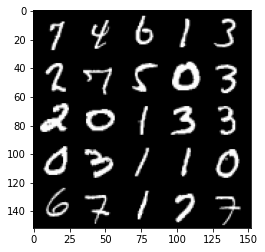

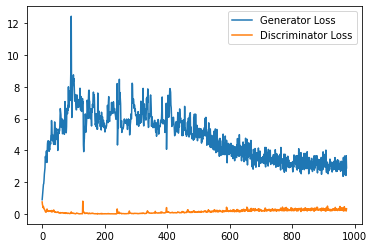

Epoch 42, step 20000: Generator loss: 3.038147697210312, discriminator loss: 0.28756011874973775


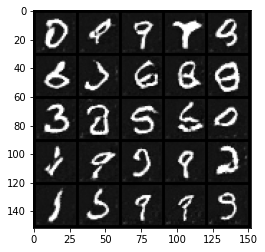

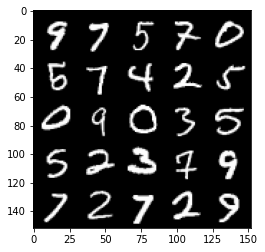

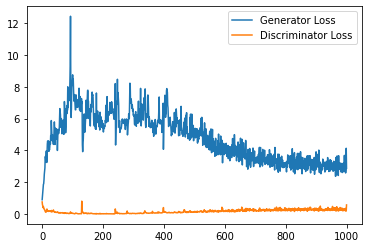

Epoch 43, step 20500: Generator loss: 2.961669181227684, discriminator loss: 0.2756729773133993


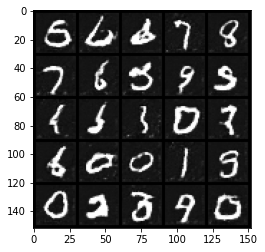

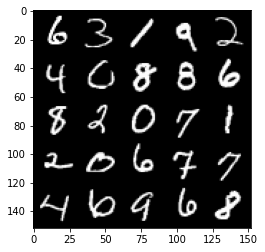

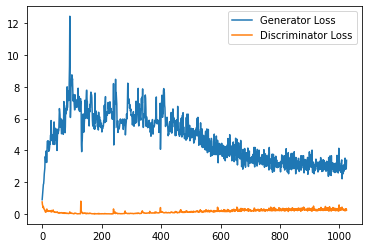

Epoch 44, step 21000: Generator loss: 2.9731139051914215, discriminator loss: 0.29210287253558637


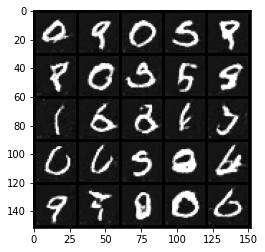

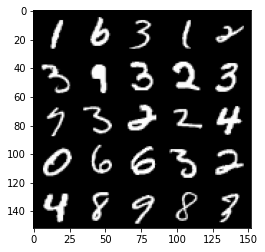

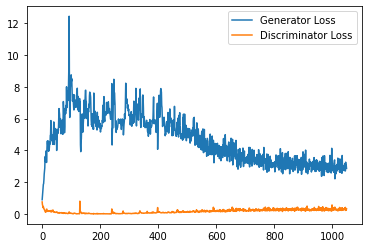

Epoch 45, step 21500: Generator loss: 2.8707749834656715, discriminator loss: 0.2886882951557636


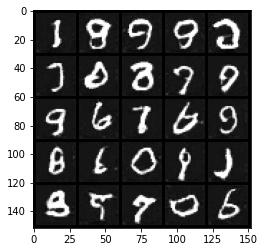

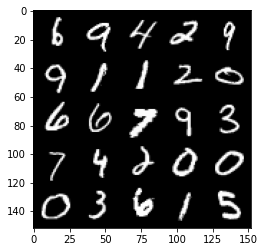

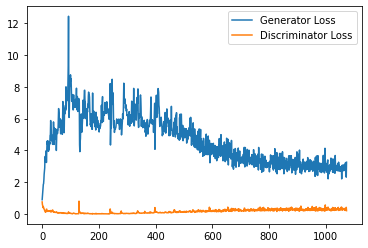

Epoch 46, step 22000: Generator loss: 2.895602949023247, discriminator loss: 0.28593095576763156


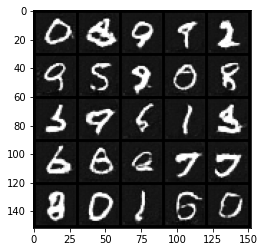

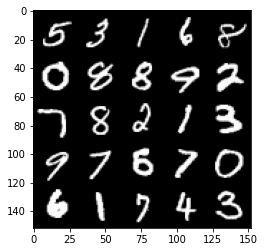

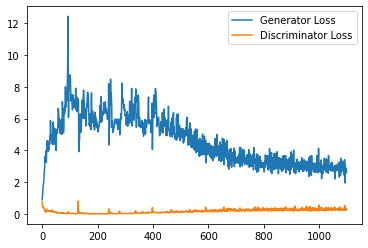

Epoch 47, step 22500: Generator loss: 3.002691268324852, discriminator loss: 0.28412409023940566


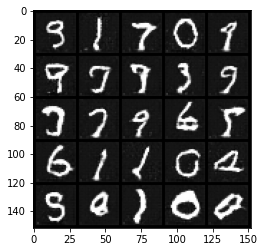

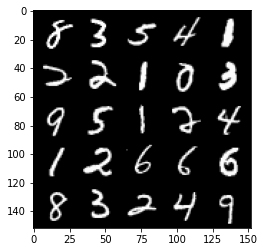

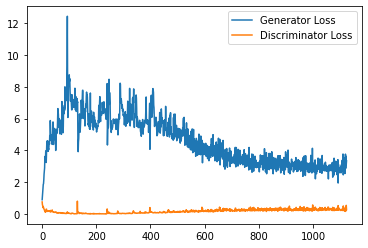

Epoch 49, step 23000: Generator loss: 2.923450103998184, discriminator loss: 0.28645632065832616


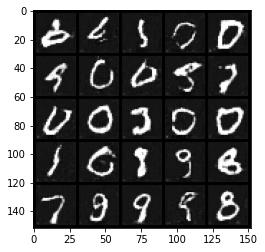

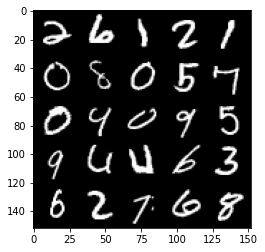

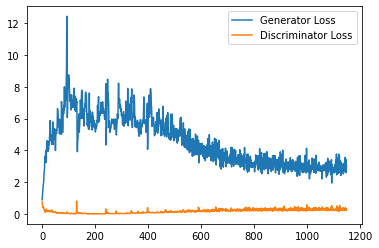

Epoch 50, step 23500: Generator loss: 2.9488804116249083, discriminator loss: 0.2815913873016834


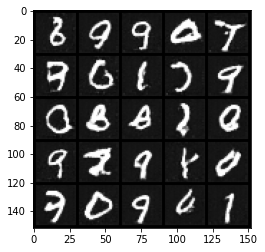

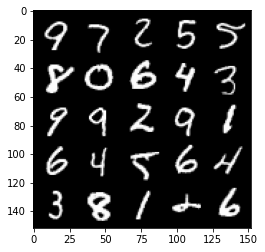

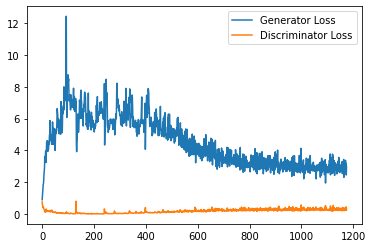

Epoch 51, step 24000: Generator loss: 2.8166019877791406, discriminator loss: 0.2880981774181128


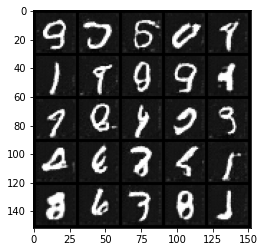

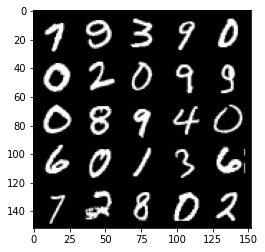

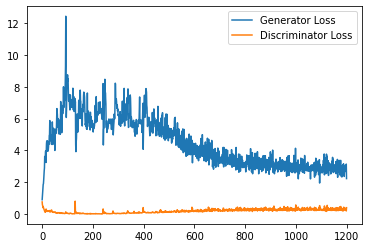

Epoch 52, step 24500: Generator loss: 2.92742211997509, discriminator loss: 0.28629149942100046


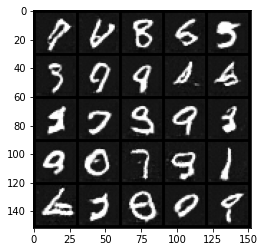

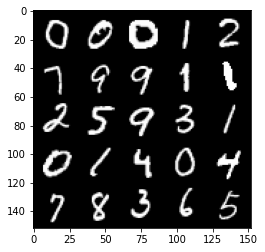

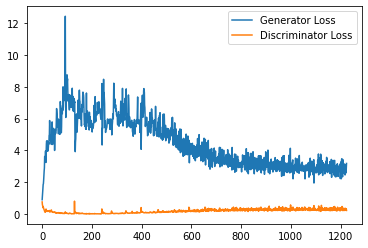

Epoch 53, step 25000: Generator loss: 2.8458479763269424, discriminator loss: 0.2877708634287119


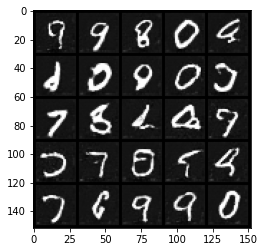

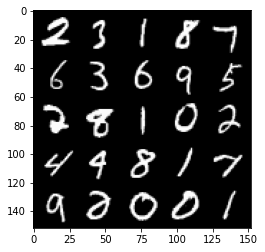

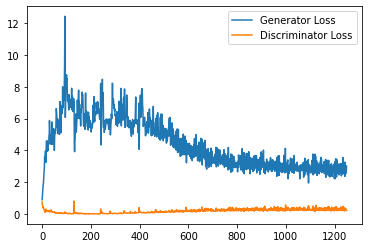

Epoch 54, step 25500: Generator loss: 2.825963757157326, discriminator loss: 0.28914713107049467


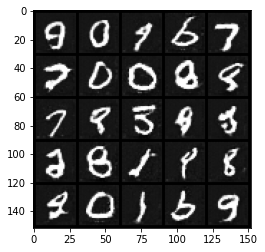

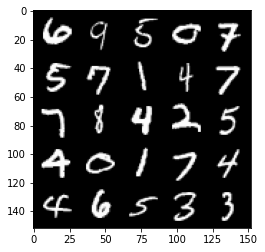

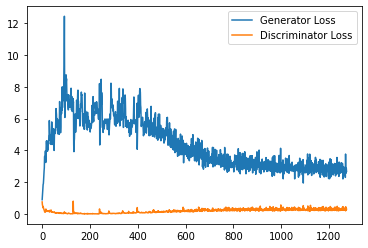

Epoch 55, step 26000: Generator loss: 2.8143911405205726, discriminator loss: 0.2829174581170082


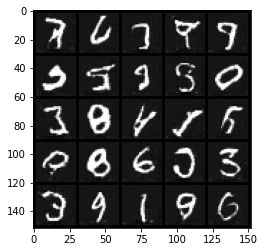

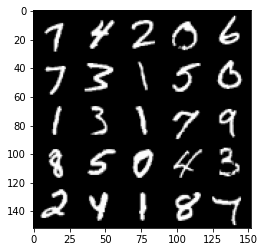

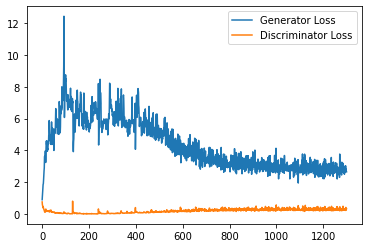

KeyboardInterrupt: 

In [7]:
cur_step = 0
generator_losses = []
discriminator_losses = []

for epoch in range(n_epochs):
    # Dataloader returns the batches and the labels
    for real, _ in tqdm(dataloader):
        cur_batch_size = len(real)
        # Flatten the batch of real images from the dataset
        real = real.to(device)

        c_labels = get_noise(cur_batch_size, c_dim, device=device)    
        ### Update discriminator ###
        # Zero out the discriminator gradients
        disc_opt.zero_grad()
        # Get noise corresponding to the current batch_size 
        fake_noise = get_noise(cur_batch_size, z_dim, device=device)
        # Combine the noise vectors and the one-hot labels for the generator
        noise_and_labels = combine_vectors(fake_noise, c_labels)
        # Generate the conditioned fake images
        fake = gen(noise_and_labels)
        
        # Get the discriminator's predictions
        disc_fake_pred, disc_q_pred = disc(fake.detach())
        disc_q_mean = disc_q_pred[:, :c_dim]
        disc_q_logvar = disc_q_pred[:, c_dim:]
        mutual_information = c_criterion(c_labels, disc_q_mean, disc_q_logvar)
        disc_real_pred, _ = disc(real)
        disc_fake_loss = adv_criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))
        disc_real_loss = adv_criterion(disc_real_pred, torch.ones_like(disc_real_pred))
        disc_loss = (disc_fake_loss + disc_real_loss) / 2 - c_lambda * mutual_information
        disc_loss.backward(retain_graph=True)
        disc_opt.step() 

        # Keep track of the average discriminator loss
        discriminator_losses += [disc_loss.item()]

        ### Update generator ###
        # Zero out the generator gradients
        gen_opt.zero_grad()

        disc_fake_pred, disc_q_pred = disc(fake)
        disc_q_mean = disc_q_pred[:, :c_dim]
        disc_q_logvar = disc_q_pred[:, c_dim:]
        mutual_information = c_criterion(c_labels, disc_q_mean, disc_q_logvar)
        gen_loss = adv_criterion(disc_fake_pred, torch.ones_like(disc_fake_pred)) - c_lambda * mutual_information
        gen_loss.backward()
        gen_opt.step()

        # Keep track of the generator losses
        generator_losses += [gen_loss.item()]

        if cur_step % display_step == 0 and cur_step > 0:
            gen_mean = sum(generator_losses[-display_step:]) / display_step
            disc_mean = sum(discriminator_losses[-display_step:]) / display_step
            print(f"Epoch {epoch}, step {cur_step}: Generator loss: {gen_mean}, discriminator loss: {disc_mean}")
            show_tensor_images(fake)
            show_tensor_images(real)
            step_bins = 20
            x_axis = sorted([i * step_bins for i in range(len(generator_losses) // step_bins)] * step_bins)
            num_examples = (len(generator_losses) // step_bins) * step_bins
            plt.plot(
                range(num_examples // step_bins), 
                torch.Tensor(generator_losses[:num_examples]).view(-1, step_bins).mean(1),
                label="Generator Loss"
            )
            plt.plot(
                range(num_examples // step_bins), 
                torch.Tensor(discriminator_losses[:num_examples]).view(-1, step_bins).mean(1),
                label="Discriminator Loss"
            )
            plt.legend()
            plt.show()
        cur_step += 1

## Exploration
You can do a bit of exploration now!

In [8]:
# Before you explore, you should put the generator
# in eval mode, both in general and so that batch norm
# doesn't cause you issues and is using its eval statistics
gen = gen.eval()

#### Changing the Latent Code Vector
You can generate some numbers with your new model! You can add interpolation as well to make it more interesting.

So starting from a image, you will produce intermediate images that look more and more like the ending image until you get to the final image. Your're basically morphing one image into another. You can choose what these two images will be using your conditional GAN.

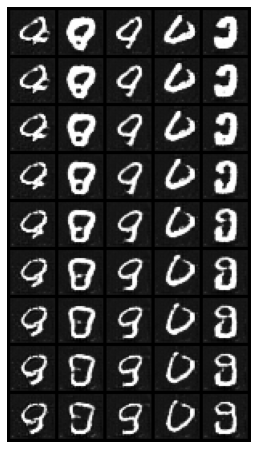

In [9]:
import math

### Change me! ###
n_interpolation = 9 # Choose the interpolation: how many intermediate images you want + 2 (for the start and end image)

def interpolate_class(n_view=5):
    interpolation_noise = get_noise(n_view, z_dim, device=device).repeat(n_interpolation, 1)
    first_label = get_noise(1, c_dim).repeat(n_view, 1)[None, :]
    second_label = first_label.clone()
    first_label[:, :, 0] =  -2
    second_label[:, :, 0] =  2
    

    # Calculate the interpolation vector between the two labels
    percent_second_label = torch.linspace(0, 1, n_interpolation)[:, None, None]
    interpolation_labels = first_label * (1 - percent_second_label) + second_label * percent_second_label
    interpolation_labels = interpolation_labels.view(-1, c_dim)

    # Combine the noise and the labels
    noise_and_labels = combine_vectors(interpolation_noise, interpolation_labels.to(device))
    fake = gen(noise_and_labels)
    show_tensor_images(fake, num_images=n_interpolation * n_view, nrow=n_view, show=False)

plt.figure(figsize=(8, 8))
interpolate_class()
_ = plt.axis('off')


You can also visualize the impact of pairwise changes of the latent code for a given noise vector.

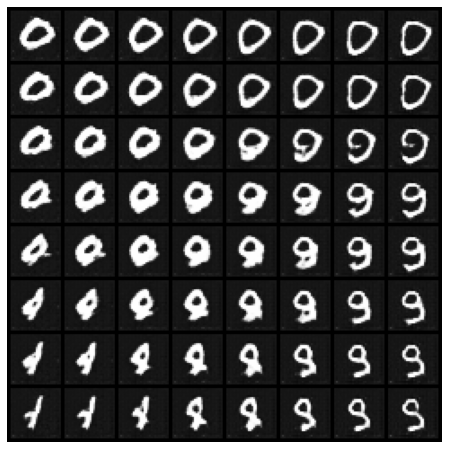

In [10]:
import math

### Change me! ###
n_interpolation = 8 # Choose the interpolation: how many intermediate images you want + 2 (for the start and end image)

def interpolate_class():
    interpolation_noise = get_noise(1, z_dim, device=device).repeat(n_interpolation * n_interpolation, 1)
    first_label = get_noise(1, c_dim).repeat(n_interpolation * n_interpolation, 1)
    
    # Calculate the interpolation vector between the two labels
    first_label = torch.linspace(-2, 2, n_interpolation).repeat(n_interpolation)
    second_label = torch.linspace(-2, 2, n_interpolation).repeat_interleave(n_interpolation)
    interpolation_labels = torch.stack([first_label, second_label], dim=1) 

    # Combine the noise and the labels
    noise_and_labels = combine_vectors(interpolation_noise, interpolation_labels.to(device))
    fake = gen(noise_and_labels)
    show_tensor_images(fake, num_images=n_interpolation * n_interpolation, nrow=n_interpolation, show=False)

plt.figure(figsize=(8, 8))
interpolate_class()
_ = plt.axis('off')
